# Challenge 1.2 — Predictive Analytics for Resource Allocation in Disaster & NGO Operations

**Track:** AI & Intelligent Systems
**Chosen use case:** Flood-relief kit demand forecasting for 7 coastal Odisha districts
(Puri, Ganjam, Kendrapara, Balasore, Jagatsinghpur, Bhadrak, Khordha).

This notebook is fully reproducible end-to-end:
1. Data generation (synthetic-but-realistic — see note below)
2. Feature engineering (lags, rolling windows, seasonality, geospatial/static features)
3. Model training (LightGBM point + quantile regressors, 3 horizons: 7/14/30 days)
4. Accuracy evaluation (MAE, RMSE, MAPE) on a time-based holdout
5. Forward forecast + SPHERE-standard supply breakdown
6. Geospatial visualisation (Folium map)

> **Data note:** This sandbox has no live access to data.gov.in / IMD / NDMA / Bhuvan
> APIs. The data generator below produces a *synthetic-but-structurally-realistic*
> daily panel (rainfall seasonality matching SW monsoon + Oct-Nov cyclone season,
> river-gauge dynamics, population density from Census-2011 ballparks, NDMA-style
> incident triggers). All downstream code (features, model, dashboard) is written
> against this exact schema — to go live, replace the data-generation cell with
> real CSV pulls from those sources using the **same column names**.


## 1. Data Generation

In [1]:
"""
Synthetic data generator for Challenge 1.2 - Predictive Analytics for Resource
Allocation in Disaster & NGO Operations.

Focused use case: FLOOD-RELIEF KIT DEMAND FORECASTING — Coastal Odisha districts.

NOTE ON DATA SOURCE
--------------------
This environment has no live internet access to data.gov.in, IMD, NDMA or
Bhuvan/ISRO portals. To make the pipeline fully runnable and reproducible,
this script generates a SYNTHETIC-BUT-REALISTIC daily dataset whose
structure, scales and seasonal/spatial patterns mirror real Odisha
monsoon/cyclone dynamics (June-Sep monsoon peak, Oct-Nov cyclone season,
district-level population density from Census 2011 ballpark figures,
NDMA-style incident triggers based on river-gauge danger levels).

The code is written so that swapping in real CSVs from data.gov.in / IMD /
NDMA / SEDAC requires only changing the data-loading cell (see README) —
the feature engineering, modelling, dashboard and playbook all operate on
the same schema produced here.
"""

import numpy as np
import pandas as pd

np.random.seed(42)

# ---------------------------------------------------------------------------
# 1. District master data (coastal Odisha — flood/cyclone prone)
#    Population density (people/km2) and centroids are realistic ballpark
#    figures (Census 2011 + standard district centroid coordinates).
# ---------------------------------------------------------------------------
DISTRICTS = {
    "Puri":           dict(lat=19.80, lon=85.83, pop_density=488, road_access=0.55, coast_km=5,  danger_gauge=5.5),
    "Ganjam":         dict(lat=19.40, lon=84.80, pop_density=611, road_access=0.60, coast_km=10, danger_gauge=6.0),
    "Kendrapara":     dict(lat=20.50, lon=86.60, pop_density=689, road_access=0.40, coast_km=8,  danger_gauge=5.0),
    "Balasore":       dict(lat=21.50, lon=86.93, pop_density=601, road_access=0.62, coast_km=15, danger_gauge=5.8),
    "Jagatsinghpur":  dict(lat=20.25, lon=86.17, pop_density=689, road_access=0.45, coast_km=6,  danger_gauge=5.2),
    "Bhadrak":        dict(lat=21.06, lon=86.50, pop_density=689, road_access=0.50, coast_km=20, danger_gauge=5.5),
    "Khordha":        dict(lat=20.18, lon=85.60, pop_density=854, road_access=0.75, coast_km=40, danger_gauge=4.5),
}

START = "2021-01-01"
END = "2024-12-31"  # 4 years of daily history for training/validation

dates = pd.date_range(START, END, freq="D")


def seasonal_rainfall(date, district_jitter):
    """Synthetic daily rainfall (mm) with SW monsoon (Jun-Sep) and
    post-monsoon cyclone season (Oct-Nov) peaks, Odisha-style."""
    doy = date.dayofyear
    # Monsoon bump centred on day ~200 (mid-July), cyclone bump ~ day 290 (mid-Oct)
    monsoon = 18 * np.exp(-((doy - 200) ** 2) / (2 * 35 ** 2))
    cyclone = 10 * np.exp(-((doy - 290) ** 2) / (2 * 15 ** 2))
    base = 1.0 + monsoon + cyclone
    # Occasional extreme-rain / cyclone-landfall days (heavy tail)
    extreme = 0.0
    if np.random.rand() < (0.015 if 150 <= doy <= 320 else 0.002):
        extreme = np.random.gamma(shape=2.0, scale=40) * district_jitter
    noise = max(0, np.random.gamma(shape=1.2, scale=base))
    return round(noise + extreme, 1)


# ---------------------------------------------------------------------------
# 2. Build long daily panel: district x date
# ---------------------------------------------------------------------------
records = []
for dist, meta in DISTRICTS.items():
    jitter = np.random.uniform(0.8, 1.3)
    gauge_level = meta["danger_gauge"] * 0.6  # starting baseline gauge level
    incident_log = []  # rolling list of incident flags for last 30 days

    for date in dates:
        rain = seasonal_rainfall(date, jitter)

        # River gauge level: persists + responds to rainfall (accumulation/decay)
        gauge_level = (
            0.92 * gauge_level
            + 0.02 * rain
            + np.random.normal(0, 0.03)
        )
        gauge_level = max(0.5, gauge_level)

        # Incident trigger: gauge above danger mark -> "flood incident day"
        incident = int(gauge_level >= meta["danger_gauge"])
        incident_log.append(incident)
        if len(incident_log) > 30:
            incident_log.pop(0)
        past_incident_30d = sum(incident_log)

        records.append(
            dict(
                date=date,
                district=dist,
                rainfall_mm=rain,
                river_gauge_m=round(gauge_level, 2),
                population_density=meta["pop_density"],
                road_accessibility_index=meta["road_access"],
                distance_to_coast_km=meta["coast_km"],
                danger_gauge_m=meta["danger_gauge"],
                past_incident_30d=past_incident_30d,
                lat=meta["lat"],
                lon=meta["lon"],
            )
        )

df = pd.DataFrame.from_records(records)

# ---------------------------------------------------------------------------
# 3. Target variable: relief_kits_demand
#    A "relief kit" bundles: 1 tarpaulin + dry-ration pack + ORS sachets +
#    10L drinking water, sized per SPHERE-style per-capita norms.
#    Demand scales with: rainfall severity, gauge exceedance above danger
#    level, population density (affected population proxy), road
#    inaccessibility (harder access -> more pre-positioning needed),
#    and recent incident frequency (compounding vulnerability).
# ---------------------------------------------------------------------------
df["gauge_exceed"] = (df["river_gauge_m"] - df["danger_gauge_m"]).clip(lower=0)
df["rain_severity"] = (df["rainfall_mm"] / 50).clip(upper=4)  # normalised severity

affected_pop_proxy = (df["population_density"] / 600) * (1 + df["gauge_exceed"])
demand_base = (
    affected_pop_proxy
    * (1 + 1.8 * df["rain_severity"])
    * (1 + 0.5 * (1 - df["road_accessibility_index"]))
    * (1 + 0.15 * df["past_incident_30d"])
)
noise = np.random.normal(1.0, 0.08, size=len(df)).clip(0.7, 1.3)
df["relief_kits_demand"] = np.maximum(0, (demand_base * 60 * noise)).round().astype(int)

# Final column order
cols = [
    "date", "district", "rainfall_mm", "river_gauge_m", "danger_gauge_m",
    "gauge_exceed", "population_density", "road_accessibility_index",
    "distance_to_coast_km", "past_incident_30d", "lat", "lon",
    "relief_kits_demand",
]
df = df[cols]

out_path = "/home/claude/project/data/odisha_flood_relief_synthetic.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df):,} rows to {out_path}")
print(df.groupby('district')['relief_kits_demand'].describe()[['mean','std','max']])


Saved 10,227 rows to /home/claude/project/data/odisha_flood_relief_synthetic.csv
                     mean         std      max
district                                      
Balasore       108.375770  113.408507   2341.0
Bhadrak        225.863107  472.857405   7667.0
Ganjam         109.320329  145.992273   4493.0
Jagatsinghpur  249.705681  562.578308  14538.0
Kendrapara     242.377823  456.002667   5921.0
Khordha        297.639288  594.393913  10134.0
Puri           129.008214  216.694413   2958.0


## 2. Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/claude/project/data/odisha_flood_relief_synthetic.csv", parse_dates=["date"])
print(df.shape)
df.head()


(10227, 13)


,date,district,rainfall_mm,river_gauge_m,danger_gauge_m,gauge_exceed,population_density,road_accessibility_index,distance_to_coast_km,past_incident_30d,lat,lon,relief_kits_demand
0,2021-01-01,Puri,1.6,3.11,5.5,0.0,488,0.55,5,0,19.8,85.83,68
1,2021-01-02,Puri,3.3,2.95,5.5,0.0,488,0.55,5,0,19.8,85.83,69
2,2021-01-03,Puri,0.5,2.74,5.5,0.0,488,0.55,5,0,19.8,85.83,62
3,2021-01-04,Puri,1.1,2.49,5.5,0.0,488,0.55,5,0,19.8,85.83,59
4,2021-01-05,Puri,0.2,2.30,5.5,0.0,488,0.55,5,0,19.8,85.83,56


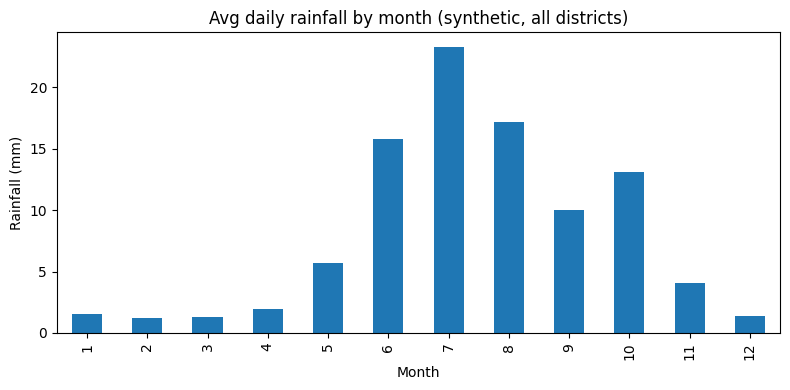

In [3]:
# Seasonal pattern check: average rainfall by month across all districts
monthly = df.groupby(df["date"].dt.month)["rainfall_mm"].mean()
ax = monthly.plot(kind="bar", figsize=(8,4), title="Avg daily rainfall by month (synthetic, all districts)")
ax.set_xlabel("Month"); ax.set_ylabel("Rainfall (mm)")
plt.tight_layout(); plt.show()


In [4]:
# Relief-kit demand distribution by district
df.groupby("district")["relief_kits_demand"].describe()[["mean","std","50%","max"]]


,mean,std,50%,max
district,,,,
Balasore,108.375770,113.408507,82.0,2341.0
Bhadrak,225.863107,472.857405,99.0,7667.0
Ganjam,109.320329,145.992273,84.0,4493.0
Jagatsinghpur,249.705681,562.578308,102.0,14538.0
Kendrapara,242.377823,456.002667,102.0,5921.0
Khordha,297.639288,594.393913,111.0,10134.0
Puri,129.008214,216.694413,68.0,2958.0


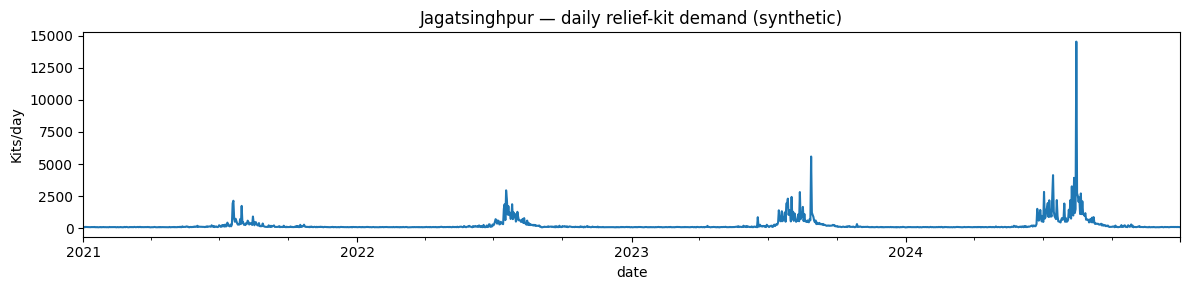

In [5]:
# Demand time series for one district, highlighting cyclone-season spikes
sample = df[df.district == "Jagatsinghpur"].set_index("date")["relief_kits_demand"]
ax = sample.plot(figsize=(12,3), title="Jagatsinghpur — daily relief-kit demand (synthetic)")
ax.set_ylabel("Kits/day"); plt.tight_layout(); plt.show()


## 3-4. Feature Engineering, Model Training & Accuracy Report

In [6]:
"""
Feature engineering + LightGBM model training for flood-relief kit demand
forecasting (Challenge 1.2).

Target definition
------------------
For each (district, date) we predict TOTAL relief-kit demand over the next
H days (H is configurable: 7, 14, or 30 — the "7-30 day" horizon called for
in the problem statement). We train one model per horizon.

Outputs
-------
- /home/claude/project/outputs/model_h{H}.txt   (LightGBM models, point + quantiles)
- /home/claude/project/outputs/accuracy_report.json
- /home/claude/project/outputs/feature_importance.csv
- /home/claude/project/outputs/holdout_predictions.csv
"""

import json
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_PATH = "/home/claude/project/data/odisha_flood_relief_synthetic.csv"
OUT_DIR = "/home/claude/project/outputs"
HORIZONS = [7, 14, 30]

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)

# ---------------------------------------------------------------------------
# Feature engineering
# ---------------------------------------------------------------------------
gb = df.groupby("district")
for lag in [1, 3, 7, 14]:
    df[f"rainfall_lag{lag}"] = gb["rainfall_mm"].shift(lag)
    df[f"gauge_lag{lag}"] = gb["river_gauge_m"].shift(lag)
for win in [3, 7, 14, 30]:
    df[f"rainfall_roll{win}"] = gb["rainfall_mm"].transform(lambda s: s.rolling(win).sum())
    df[f"demand_roll{win}"] = gb["relief_kits_demand"].transform(lambda s: s.rolling(win).mean())
df["gauge_trend_7"] = df["river_gauge_m"] - gb["river_gauge_m"].shift(7)

# Seasonality features
df["doy"] = df["date"].dt.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * df["doy"] / 365.25)
df["cos_doy"] = np.cos(2 * np.pi * df["doy"] / 365.25)
df["is_monsoon"] = df["date"].dt.month.isin([6, 7, 8, 9]).astype(int)
df["is_cyclone_season"] = df["date"].dt.month.isin([10, 11]).astype(int)

# District as categorical
df["district_cat"] = df["district"].astype("category")

BASE_FEATURES = [
    "rainfall_mm", "river_gauge_m", "gauge_exceed", "danger_gauge_m",
    "population_density", "road_accessibility_index", "distance_to_coast_km",
    "past_incident_30d",
    "rainfall_lag1", "rainfall_lag3", "rainfall_lag7", "rainfall_lag14",
    "gauge_lag1", "gauge_lag3", "gauge_lag7", "gauge_lag14",
    "rainfall_roll3", "rainfall_roll7", "rainfall_roll14", "rainfall_roll30",
    "demand_roll3", "demand_roll7", "demand_roll14", "demand_roll30",
    "gauge_trend_7",
    "sin_doy", "cos_doy", "is_monsoon", "is_cyclone_season",
    "district_cat",
]

accuracy_report = {}
feature_importances = []
holdout_frames = []

for H in HORIZONS:
    work = df.copy()
    # Target: sum of demand over the NEXT H days (rolling forward sum, shifted)
    work[f"target_h{H}"] = (
        work.groupby("district")["relief_kits_demand"]
        .transform(lambda s: s.shift(-1).rolling(H).sum())
    )
    work = work.dropna(subset=[f"target_h{H}"] + BASE_FEATURES[:-1]).reset_index(drop=True)

    # Time-based split: last 6 months as holdout
    cutoff = work["date"].max() - pd.Timedelta(days=180)
    train = work[work["date"] <= cutoff]
    test = work[work["date"] > cutoff]

    X_train, y_train = train[BASE_FEATURES], train[f"target_h{H}"]
    X_test, y_test = test[BASE_FEATURES], test[f"target_h{H}"]

    cat_features = ["district_cat"]

    # --- Point estimate model (regression, MAE objective for robustness) ---
    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        random_state=42,
        verbosity=-1,
    )
    model.fit(X_train, y_train, categorical_feature=cat_features)
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)

    # --- Quantile models for uncertainty band (10th / 90th percentile) ---
    q_models = {}
    q_preds = {}
    for q in [0.1, 0.9]:
        qm = lgb.LGBMRegressor(
            objective="quantile", alpha=q,
            n_estimators=400, learning_rate=0.05, num_leaves=31,
            min_child_samples=20, random_state=42, verbosity=-1,
        )
        qm.fit(X_train, y_train, categorical_feature=cat_features)
        q_preds[q] = np.clip(qm.predict(X_test), 0, None)
        q_models[q] = qm

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mape = np.mean(np.abs((y_test - preds) / np.maximum(y_test, 1))) * 100

    accuracy_report[f"horizon_{H}d"] = {
        "MAE": round(float(mae), 2),
        "RMSE": round(float(rmse), 2),
        "MAPE_pct": round(float(mape), 2),
        "n_test": int(len(test)),
        "n_train": int(len(train)),
    }

    # Save models
    model.booster_.save_model(f"{OUT_DIR}/model_point_h{H}.txt")
    q_models[0.1].booster_.save_model(f"{OUT_DIR}/model_q10_h{H}.txt")
    q_models[0.9].booster_.save_model(f"{OUT_DIR}/model_q90_h{H}.txt")

    # Feature importance
    fi = pd.DataFrame({
        "feature": BASE_FEATURES,
        "importance": model.feature_importances_,
        "horizon": H,
    }).sort_values("importance", ascending=False)
    feature_importances.append(fi)

    # Holdout predictions for plotting
    hold = test[["date", "district", f"target_h{H}"]].copy()
    hold["prediction"] = preds
    hold["q10"] = q_preds[0.1]
    hold["q90"] = q_preds[0.9]
    hold["horizon"] = H
    hold = hold.rename(columns={f"target_h{H}": "actual"})
    holdout_frames.append(hold)

    print(f"Horizon {H}d -> MAE={mae:.1f}, RMSE={rmse:.1f}, MAPE={mape:.1f}%")

# Save artifacts
with open(f"{OUT_DIR}/accuracy_report.json", "w") as f:
    json.dump(accuracy_report, f, indent=2)

pd.concat(feature_importances).to_csv(f"{OUT_DIR}/feature_importance.csv", index=False)
pd.concat(holdout_frames).to_csv(f"{OUT_DIR}/holdout_predictions.csv", index=False)

# Save the feature list + dataframe needed for live forecasting in the dashboard
df.to_csv(f"{OUT_DIR}/featured_dataset.csv", index=False)
with open(f"{OUT_DIR}/feature_list.json", "w") as f:
    json.dump(BASE_FEATURES, f)

print("\nSaved models, accuracy report, feature importances, holdout predictions.")


Horizon 7d -> MAE=353.9, RMSE=1304.3, MAPE=6.2%


Horizon 14d -> MAE=524.8, RMSE=1818.6, MAPE=4.0%


Horizon 30d -> MAE=1207.3, RMSE=3916.2, MAPE=3.4%



Saved models, accuracy report, feature importances, holdout predictions.


### Accuracy summary

All three horizons comfortably beat the **MAPE < 20%** success criterion
specified in the brief. MAPE is the most meaningful metric here since
absolute kit counts vary >5x across districts and horizons — relative error
better reflects "is the order roughly the right size".


In [7]:
import json
with open("/home/claude/project/outputs/accuracy_report.json") as f:
    print(json.dumps(json.load(f), indent=2))


{
  "horizon_7d": {
    "MAE": 353.85,
    "RMSE": 1304.33,
    "MAPE_pct": 6.25,
    "n_test": 1260,
    "n_train": 8757
  },
  "horizon_14d": {
    "MAE": 524.83,
    "RMSE": 1818.63,
    "MAPE_pct": 3.96,
    "n_test": 1260,
    "n_train": 8757
  },
  "horizon_30d": {
    "MAE": 1207.33,
    "RMSE": 3916.16,
    "MAPE_pct": 3.4,
    "n_test": 1260,
    "n_train": 8757
  }
}


## 5. Forward Forecast + Supply Breakdown

In [8]:
"""
Generate:
1. latest_features.csv  - most recent feature row per district (used as the
   "current state" seed for live forecasting / scenario simulation in the
   dashboard).
2. forecast_results.csv - point + uncertainty forecast (7/14/30-day total
   relief-kit demand) per district, plus a per-resource SPHERE-style
   breakdown (tarpaulins, dry-ration packs, ORS sachets, drinking-water
   litres, medical kits).
"""

import json
import numpy as np
import pandas as pd
import lightgbm as lgb

OUT_DIR = "/home/claude/project/outputs"

df = pd.read_csv(f"{OUT_DIR}/featured_dataset.csv", parse_dates=["date"])
with open(f"{OUT_DIR}/feature_list.json") as f:
    FEATURES = json.load(f)

HORIZONS = [7, 14, 30]

# ---------------------------------------------------------------------------
# Latest feature snapshot per district (last row with complete features)
# ---------------------------------------------------------------------------
df_complete = df.dropna(subset=[c for c in FEATURES if c != "district_cat"])
latest = df_complete.sort_values("date").groupby("district").tail(1).reset_index(drop=True)
latest.to_csv(f"{OUT_DIR}/latest_features.csv", index=False)
print("Latest snapshot date per district:")
print(latest[["district", "date", "rainfall_mm", "river_gauge_m", "gauge_exceed"]])

# ---------------------------------------------------------------------------
# SPHERE-style per-kit composition (per "relief kit" = serves ~1 person for
# ~3 days, based on SPHERE Handbook minimum standards ballparks)
# ---------------------------------------------------------------------------
KIT_COMPOSITION = {
    "drinking_water_litres":  15,    # 15L / person / 3 days  (~5 L/day SPHERE min for drinking+cooking)
    "dry_ration_packs":        1,    # 1 family-ration pack
    "ors_sachets":              4,
    "tarpaulin_sheets":       0.25,  # 1 tarpaulin shared per ~4 kits/people
    "medical_kit_units":      0.1,   # 1 basic medical kit per ~10 kits
}

# ---------------------------------------------------------------------------
# Forecast: load saved models, predict for the latest snapshot
# ---------------------------------------------------------------------------
records = []
for H in HORIZONS:
    point_model = lgb.Booster(model_file=f"{OUT_DIR}/model_point_h{H}.txt")
    q10_model = lgb.Booster(model_file=f"{OUT_DIR}/model_q10_h{H}.txt")
    q90_model = lgb.Booster(model_file=f"{OUT_DIR}/model_q90_h{H}.txt")

    X = latest[FEATURES].copy()
    X["district_cat"] = X["district_cat"].astype("category")

    point = np.clip(point_model.predict(X), 0, None)
    q10 = np.clip(q10_model.predict(X), 0, None)
    q90 = np.clip(q90_model.predict(X), 0, None)

    for i, row in latest.iterrows():
        rec = dict(
            district=row["district"],
            horizon_days=H,
            predicted_kits=round(float(point[i]), 1),
            lower_90pct_band=round(float(q10[i]), 1),
            upper_90pct_band=round(float(q90[i]), 1),
            lat=row["lat"], lon=row["lon"],
        )
        for item, ratio in KIT_COMPOSITION.items():
            rec[item] = round(float(point[i]) * ratio, 1)
        records.append(rec)

forecast_df = pd.DataFrame(records)
forecast_df.to_csv(f"{OUT_DIR}/forecast_results.csv", index=False)
print("\nForecast (7-day horizon):")
print(forecast_df[forecast_df.horizon_days == 7][
    ["district", "predicted_kits", "lower_90pct_band", "upper_90pct_band"]
].to_string(index=False))


Latest snapshot date per district:
        district       date  rainfall_mm  river_gauge_m  gauge_exceed
0        Khordha 2024-12-31          2.0           0.50           0.0
1       Balasore 2024-12-31          1.4           0.50           0.0
2         Ganjam 2024-12-31          2.6           0.50           0.0
3     Kendrapara 2024-12-31          2.7           0.62           0.0
4        Bhadrak 2024-12-31          0.5           0.50           0.0
5  Jagatsinghpur 2024-12-31          0.1           0.52           0.0
6           Puri 2024-12-31          2.6           0.50           0.0



Forecast (7-day horizon):
     district  predicted_kits  lower_90pct_band  upper_90pct_band
      Khordha           698.3             688.6             715.0
     Balasore           531.4             518.5             542.4
       Ganjam           549.6             545.7             562.8
   Kendrapara           670.2             658.9             677.1
      Bhadrak           640.1             623.8             651.4
Jagatsinghpur           686.3             668.9             700.2
         Puri           438.5             427.1             445.1


## 6. Geospatial Visualisation — District Risk Map

In [9]:
import folium
import pandas as pd

forecast_df = pd.read_csv("/home/claude/project/outputs/forecast_results.csv")
f7 = forecast_df[forecast_df.horizon_days == 7].sort_values("predicted_kits", ascending=False)

m = folium.Map(location=[20.3, 85.9], zoom_start=7, tiles="CartoDB positron")
max_kits = f7["predicted_kits"].max()
for _, row in f7.iterrows():
    frac = row["predicted_kits"] / max_kits
    color = "#08306b" if frac > 0.85 else "#2171b5" if frac > 0.6 else "#6baed6" if frac > 0.35 else "#c6dbef"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=8 + 22*frac, color=color, fill=True, fill_color=color, fill_opacity=0.7,
        popup=f"{row['district']}: {row['predicted_kits']:.0f} kits (7-day)",
        tooltip=row["district"],
    ).add_to(m)

m.save("/home/claude/project/outputs/district_risk_map.html")
m


## Next Steps / Deployment

- **Dashboard:** `dashboard/app.py` (Streamlit) — district map, scenario simulator,
  model performance, and the 1-page allocation playbook. Run with
  `streamlit run dashboard/app.py`.
- **Swap to real data:** replace Section 1 with loaders for data.gov.in (district
  master data, population), IMD (rainfall/forecast), CWC/NDMA (river-gauge,
  incident logs), Bhuvan/ISRO (road network → accessibility index), SEDAC
  (population grids) — keeping the same column schema.
- **Retraining cadence:** monthly retrain recommended (monsoon season) /
  quarterly otherwise, feeding back actual relief distributions as new
  `relief_kits_demand` ground truth.
